In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
%matplotlib inline
print("Libraries loaded!")

Libraries loaded!


In [8]:
df = pd.read_csv("../data/raw/Mental_Health_Lifestyle_Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (3000, 12)


,Country,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,Brazil,48,Male,Low,Vegetarian,6.3,Low,NaN,21,4.0,7.8,6.5
1,Australia,31,Male,Moderate,Vegan,4.9,Low,PTSD,48,5.2,8.2,6.8
2,Japan,37,Female,Low,Vegetarian,7.2,High,NaN,43,4.7,9.6,9.7
3,Brazil,35,Male,Low,Vegan,7.2,Low,Depression,43,2.2,8.2,6.6
4,Germany,46,Male,Low,Balanced,7.3,Low,Anxiety,35,3.6,4.7,4.4


In [9]:
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Data Types ===
Country                         object
Age                              int64
Gender                          object
Exercise Level                  object
Diet Type                       object
Sleep Hours                    float64
Stress Level                    object
Mental Health Condition         object
Work Hours per Week              int64
Screen Time per Day (Hours)    float64
Social Interaction Score       float64
Happiness Score                float64
dtype: object

=== Missing Values ===
Country                          0
Age                              0
Gender                           0
Exercise Level                   0
Diet Type                        0
Sleep Hours                      0
Stress Level                     0
Mental Health Condition        595
Work Hours per Week              0
Screen Time per Day (Hours)      0
Social Interaction Score         0
Happiness Score                  0
dtype: int64


Mental Health Condition
Anxiety       628
PTSD          624
Depression    580
Bipolar       573
Name: count, dtype: int64


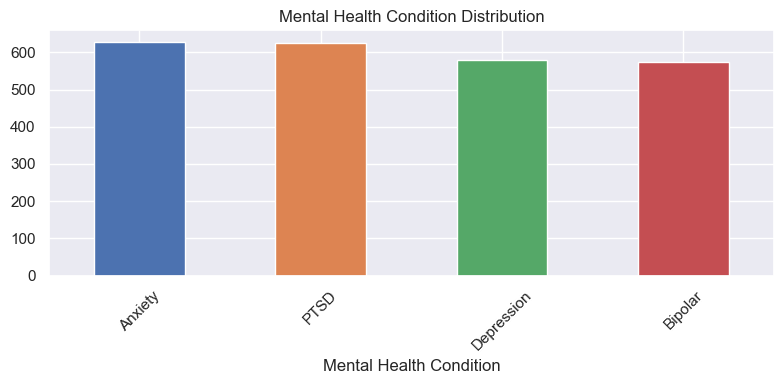

In [14]:
# Correct target column
target_col = "Mental Health Condition"
print(df[target_col].value_counts())

plt.figure(figsize=(8,4))
df[target_col].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title("Mental Health Condition Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

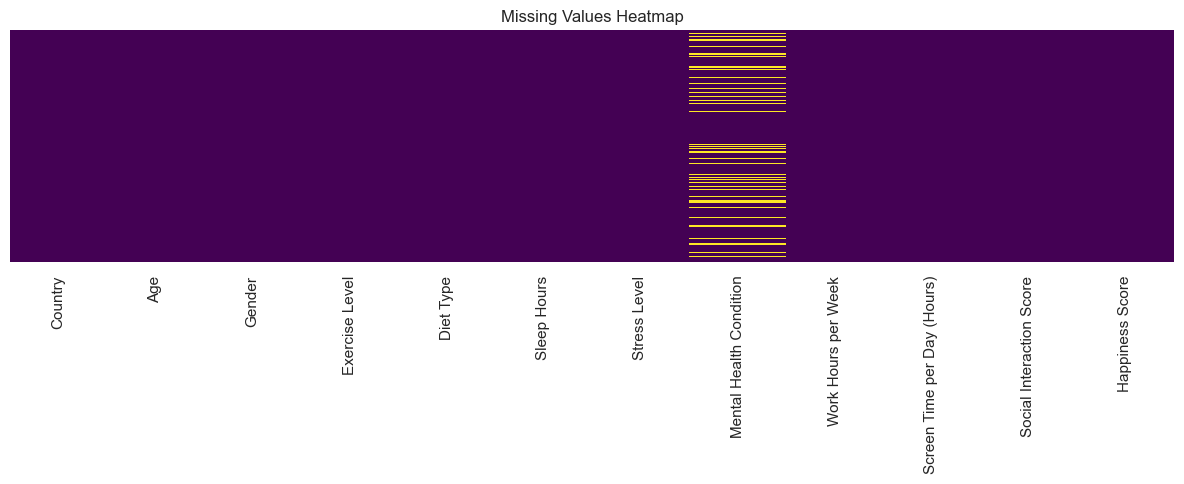

In [11]:
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

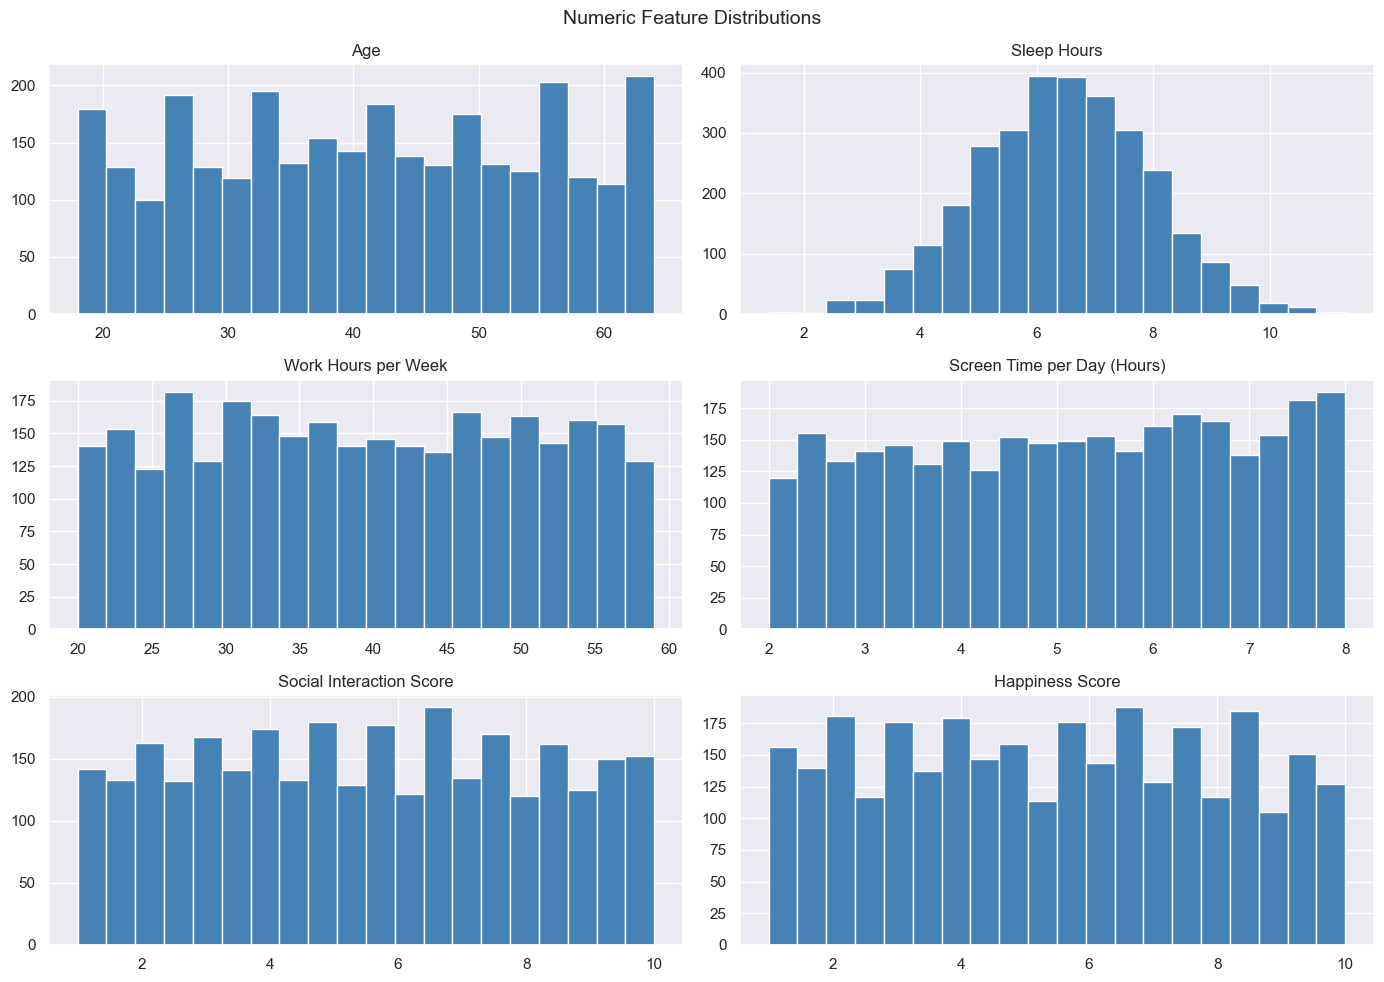

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols].hist(figsize=(14,10), bins=20, color='steelblue', edgecolor='white')
plt.suptitle("Numeric Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

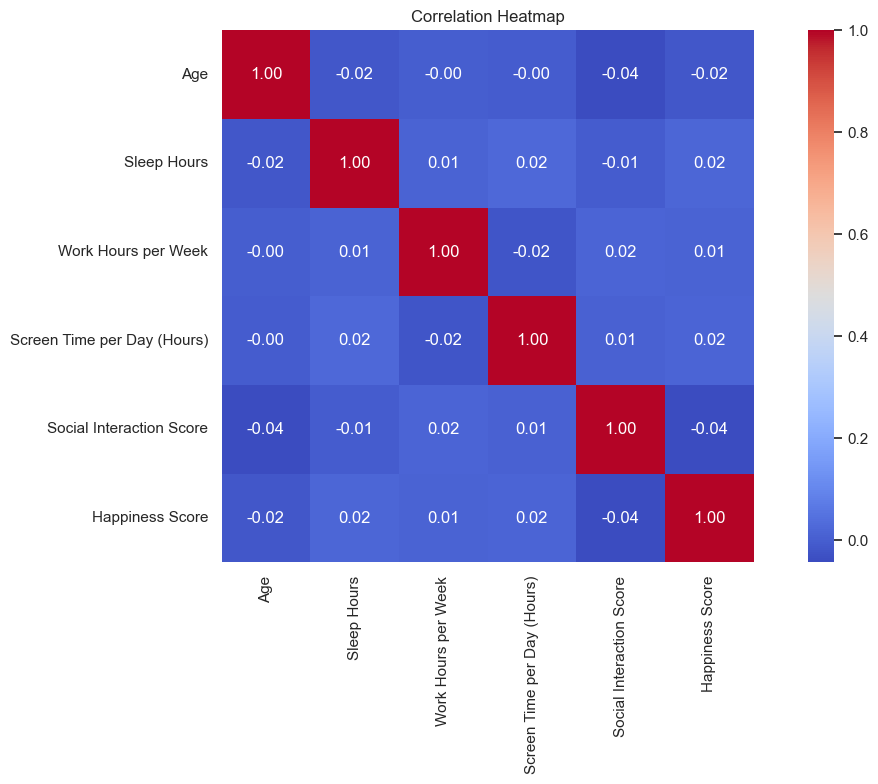

In [13]:
plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Key Insights

- Dataset contains 3,000 records across 12 features (2019–2024)
- Target: Mental Health Condition — 4 classes: Anxiety, PTSD, Depression, Bipolar
- Classes are well balanced (~570–630 each) — no resampling needed
- 595 missing values in target column (~20%) — will be dropped in preprocessing
- Numeric features show near-zero correlations — categorical features carry most predictive signal
- Sleep Hours peaks at 6–7hrs, slightly below healthy recommendations
- Age is uniformly distributed (18–65) — no age group bias in the data